In [1]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import math as mt
import plotly.express as px
import plotly.graph_objects as go
from scipy.integrate import quad, dblquad
import sympy as sp
import nbformat

# **Punto 1**

**Consistencia de un estimador**

Un estimador $\hat{\theta}$ se dice consistente si, para cualquier $\varepsilon > 0$,

$$
P\left(|\hat{\theta} - \theta| \geq \varepsilon\right) \to 0
\quad \text{cuando} \quad n \to \infty.
$$

Es decir, $\hat{\theta}$ es consistente si, a medida que el tamaño de la muestra crece, cada vez es menos probable que $\hat{\theta}$ esté a una distancia mayor que $\varepsilon$ del valor verdadero de $\theta$.

Demuestre que $\bar{X}$ es un estimador consistente de $\mu$ cuando $\sigma^2 < \infty$ utilizando la desigualdad de Chebyshev.

*Sugerencia:* la desigualdad puede escribirse como

$$
P\left(|Y - \mu_Y| \geq \varepsilon\right) \leq \frac{\sigma_Y^2}{\varepsilon^2}.
$$

Ahora identifique $Y$ con $\bar{X}$.

**Sln:**

Sabemos que: 

$P(\left(|X - \mu| \geq \varepsilon\right) \leq \frac{Var(X)}{\varepsilon^2}$

pero 

$ Var(X) = \frac{\sigma^2}{n} \implies var(X) -> 0 \quad \text{si} \quad n-> \infty$

por lo tanto: 

$P(\left(|X - \mu| \geq \varepsilon\right)
 \leq 0 = 0 $

Se concluye que $\bar{X}$ es un estimador consistente de $\mu$, probemoslo computacionalmente:

Primero, los parametros ($\mu$, $\sigma$) de una población arbitrarias, supondremos una fdp $f(x)$ y un conjunto de tamaños muestrales. Luego veremos la tendencia de:

$$
P(|\bar{X} - \mu| \geq \epsilon)
$$

Supondremos que $X \sim \chi^2{(k)}$

Asi, $E[X] = k \quad \wedge \quad V[X] = 2k$ 

In [2]:
from funciones_locales import chi2

# definimos el k poblcional de k 
k = 6.2 

# definimos mu y sigma poblacionales

mu = k 
sigma2 = 2*k
sigma = np.sqrt(sigma2)




A partir de esto, calculamos $\mu_X$ 

# **Punto 2**

Edades de cúmulos estelares. La siguiente información muestra la edad (Gyr) de algunos cúmulos estelares masivos observados en la galaxia, calculadas con modelos de evolución estelar:

`np.array([9.7, 7.7, 7.4, 9.7, 7.8, 
            11.8, 8.2, 11.3, 8.7, 6.8, 
            5.9, 7.2, 7.3, 6.3, 9.0,
            7.9, 6.3, 7.6, 10.7, 6.5, 
            7.0, 8.1, 6.8, 7.0, 7.8, 
            7.7, 11.6])`

In [3]:
# Muestra de la poblacion de los años de cumulos estelares
X = np.array([9.7, 7.7, 7.4, 9.7, 7.8, 
            11.8, 8.2, 11.3, 8.7, 6.8, 
            5.9, 7.2, 7.3, 6.3, 9.0,
            7.9, 6.3, 7.6, 10.7, 6.5, 
            7.0, 8.1, 6.8, 7.0, 7.8, 
            7.7, 11.6])

**a)** Establezca un estimador para el valor medio de la edad de todos los cúmulos estelares masivos en la galaxia y estime.

In [4]:
# definimos el estimador media 

def muhat(x):
    return np.sum(x)/len(x)

# calculamos el valor de la media muestral
medX = muhat(X)

print('la edad promedio de cumulos estelares es: ', medX, 'Gyr')

la edad promedio de cumulos estelares es:  8.14074074074074 Gyr


**b)** Haga una estimación puntual del valor de la edad que separa al 50 % de los cúmulos más jóvenes de la galaxia del 50 % de los cúmulos más viejos. Establezca el estimador que va a usar.

**Sln** Se elige como estimador del percentil 50 a el estimador *mediana*:

In [5]:
def mediana(x):
    x_ordenado = np.sort(x)
    n = len(x_ordenado)

    if n % 2 == 0: 
        mediana = (x_ordenado[n//2 - 1] + x_ordenado[n//2]) / 2
    else:
        mediana = x_ordenado[n//2]

    return mediana

medianaX = mediana(X)

print('la edad mediana de cumulos estelares es: ', medianaX, 'Gyr')

la edad mediana de cumulos estelares es:  7.7 Gyr


**c)** Calcule e interprete una estimación puntual de la desviación estándar $\sigma$ de toda la población. ¿Qué estimador va a usar?

**Sln** Para esto, se usa el estimador $\hat{S}$:
$$
\hat{S}^2(X) = \frac{\sum_i (X_i - \bar{X})^2}{n - 1}
$$

In [6]:
# estimacion de la varianza muestral

def varianza_muestral(x):
    n = len(x)
    media = muhat(x)
    varianza = np.sum((x - media) ** 2) / (n - 1)
    return varianza

varianzaX = varianza_muestral(X)

print('la varianza muestral de las edades de cumulos estelares es: ', varianzaX, 'Gyr^2')
print('la desviación estándar muestral de las edades de cumulos estelares es: ', np.sqrt(varianzaX), 'Gyr')

la varianza muestral de las edades de cumulos estelares es:  2.754045584045584 Gyr^2
la desviación estándar muestral de las edades de cumulos estelares es:  1.659531736377941 Gyr


**d)** Haga una estimación puntual de la proporción de todos los cúmulos cuya edad excede los 10 Gyr.

**Sln** El estimador que se usara para determinarlo será:

$$
\hat{p} = \frac{x}{n}
$$

In [7]:
prop_mayor_10 = np.sum(X > 10) / len(X)

print('la proporción de cumulos estelares con edad mayor a 10 Gyr es: ', prop_mayor_10)

la proporción de cumulos estelares con edad mayor a 10 Gyr es:  0.14814814814814814


**e)** Haga una estimación puntual del coeficiente de variación $\sigma/\mu$. ¿Qué estimador va a usar?

# **Punto 3**

**¿Con o sin azúcar?**

De un número $n_1$ de hombres seleccionados aleatoriamente, $X_1$ toman tinto con azúcar, mientras que de $n_2$ mujeres, $X_2$ toman tinto con azúcar. Sean $p_1$ y $p_2$ las probabilidades de que un hombre y una mujer, respectivamente, seleccionados aleatoriamente tomen tinto con azúcar.

**a)** Muestre que $\left(\frac{X_1}{n_1}\right) - \left(\frac{X_2}{n_2}\right)$ es un estimador no sesgado para $p_1 - p_2$.

**Respuesta**


$E \left[\left(\frac{X_1}{n_1}\right) - \left(\frac{X_2}{n_2}\right)\right] = \frac{1}{n_1} E(X_1) - \frac{1}{n_2} E(X_2) = \frac{n_1}{n_1} p_1 - \frac{n_2}{n_2} p_2 = p_1 - p_2$

In [8]:
# definimos el estimador de probabilidad de diferencia
def estimador_dif(x1, n1, x2, n2):
    return (x1 / n1) - (x2 / n2)

**b)** ¿Cuál es el error estándar de este estimador?

**Respuesta**


$
\sigma(\hat{p}_1 - \hat{p}_2) = \sqrt{\frac{p_1 q_1}{n_1} + \frac{p_2 q_2}{n_2}}
$

In [9]:
# Definamos el estimado del error estandar de la diferencia de proporciones

def error_estandar_dif(p1, n1, p2, n2):
    q1, q2 = 1 - p1, 1 - p2
    return np.sqrt((p1 * q1 / n1) + (p2 * q2 / n2))

**c)** ¿Cómo usaría los valores observados $x_1$ y $x_2$ para estimar el error estándar de su estimador?

**Respuesta:**
$$
\hat{\sigma}(\hat{p}_1-\hat{p}_2) = \sqrt{\frac{\hat{p}_1 (1 - \hat{p}_1)}{n_1} - \frac{\hat{p}_2 (1 - \hat{p}_2)}{n_2}}
$$

**d)** Si $n_1 = n_2 = 200$, $x_1 = 127$ y $x_2 = 176$, use el estimador del literal **a)** para obtener una estimación de $p_1 - p_2$.

In [10]:
x1 = 127
n1 = 200
p1 = x1 / n1

x2 = 176
n2 = 200
p2 = x2 / n2

print(p1, p2, p1 - p2)

0.635 0.88 -0.245


**e)** Use los datos anteriores para estimar el error estándar del estimador.

In [11]:



dif_proporciones = estimador_dif(x1, n1, x2, n2)
error_dif = error_estandar_dif(p1, n1, p2, n2)

print('la diferencia de proporciones es: ', dif_proporciones)
print('el error estandar de la diferencia de proporciones es: ', error_dif)



la diferencia de proporciones es:  -0.245
el error estandar de la diferencia de proporciones es:  0.041071583850638145


## **Punto 4**

**Distribución de Weibull**

**a)** Consulte qué es la distribución de Weibull, escriba su función de densidad de probabilidad (pdf) y grafíquela.

La fdp de weibull es la siguiente:

$$
f(x; \alpha, \beta) = \frac{\alpha}{\beta} \, \frac{x}{\beta}^{\alpha - 1} \, e^{-(\frac{x}{\beta})^{\alpha}}
$$

In [ ]:
from funciones_locales import weibull

**Gráficas** vamos a gráficar variando los parametros $\lambda$ y $K$

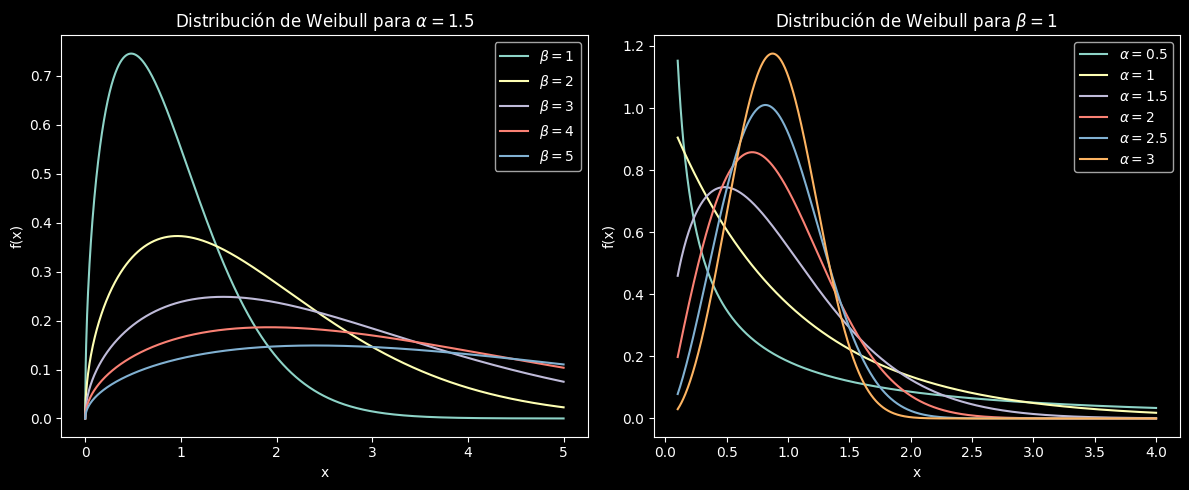

In [25]:
figweibull, axweibull = plt.subplots(1, 2, figsize=(12, 5))

x = np.linspace(0, 20, 1000)
xs2 = np.linspace(0, 5, 1000)
xs3 = np.linspace(0.1, 4, 1000)

betas = [1, 2, 3, 4, 5]
alphas = [0.5, 1, 1.5, 2, 2.5, 3]

for lam in betas:
    axweibull[0].plot(xs2, weibull(xs2, 1.5, lam), label=fr'$\beta={lam}$')
axweibull[0].set_title(r'Distribución de Weibull para $\alpha=1.5$')
axweibull[0].legend()
axweibull[0].set_xlabel('x', color='white')
axweibull[0].set_ylabel('f(x)', color='white')
axweibull[0].tick_params(axis='x', colors='white')
axweibull[0].tick_params(axis='y', colors='white')

for k in alphas:
    axweibull[1].plot(xs3, weibull(xs3, k, 1), label=fr'$\alpha={k}$')
axweibull[1].set_title(r'Distribución de Weibull para $\beta=1$')
axweibull[1].legend()
axweibull[1].set_xlabel('x', color='white')
axweibull[1].set_ylabel('f(x)', color='white')
axweibull[1].tick_params(axis='x', colors='white')
axweibull[1].tick_params(axis='y', colors='white')

plt.tight_layout()
plt.show()


**b)** Sea $X$ una variable aleatoria con distribución de Weibull con parámetros $\alpha$ y $\beta$, de modo que:

$$
\mathbb{E}(X)=\beta\,\Gamma\!\left(1+\frac{1}{\alpha}\right)
$$

$$
\mathrm{Var}(X)=\beta^2\left\{\Gamma\!\left(1+\frac{2}{\alpha}\right)-\left[\Gamma\!\left(1+\frac{1}{\alpha}\right)\right]^2\right\}
$$

Basándose en una muestra $X_1,\ldots,X_n$, utilice el método de los momentos para escribir las ecuaciones de los estimadores de $\alpha$ y $\beta$. Muestre que, una vez obtenido el estimador de $\alpha$, el estimador de $\beta$ puede obtenerse a partir de la función gamma, y que el estimador de $\alpha$ se obtiene de una ecuación que involucra la función gamma.

Ahora, sean $n=20$, $\bar{x}=28.0$ y $\sum_i x_i^2=16500$, estime los parámetros $\beta$ y $\alpha$.

**Ayuda:**

$$
\frac{[\Gamma(1.2)]^2}{\Gamma(1.4)}=0.95
$$

Se obtiene que $\hat{\alpha} \approx 5$ y $\hat{\beta} \approx 30$ grafiquemos esta distribución:

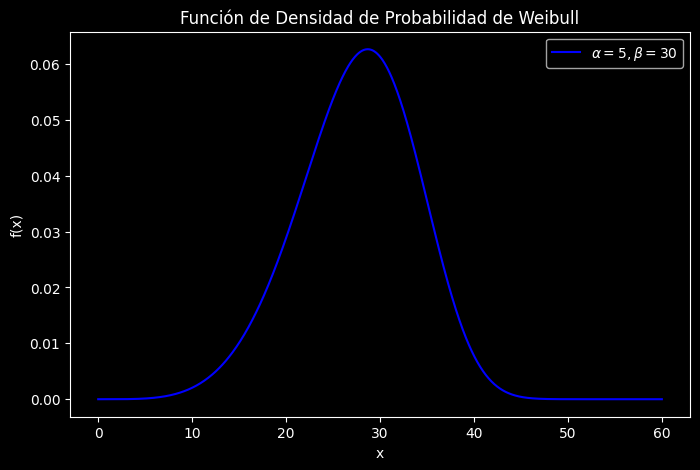

In [21]:
weibull_fdp = weibull(x, 5, 30)
xs = np.linspace(0, 60, 1000)

# graficamos la función de densidad de probabilidad de Weibull
plt.figure(figsize=(8, 5))
plt.style.use('dark_background')

# lo ponemos lindo, graficamos en modo oscuro 
plt.gca().set_facecolor('black')
plt.gca().spines['bottom'].set_color('white')
plt.gca().spines['left'].set_color('white')
plt.gca().spines['top'].set_color('white')
plt.gca().spines['right'].set_color('white')
plt.gca().tick_params(axis='x', colors='white')
plt.gca().tick_params(axis='y', colors='white')

plt.plot(xs, weibull(xs, 5, 30), label=r'$\alpha=5, \beta=30$', color='blue')
plt.title('Función de Densidad de Probabilidad de Weibull', color='white')
plt.xlabel('x', color='white')
plt.ylabel('f(x)', color='white')
plt.legend()
plt.show()





## **Punto 5**

**Edades de estrellas**

Se calculan las edades de algunas estrellas dentro de cierto cúmulo de estrellas joven (en millones de años):

$392,\ 376,\ 401,\ 367,\ 389,\ 362,\ 409,\ 415,\ 358,\ 375.$

**a)** Suponiendo que la edad de las estrellas en esta región sigue una distribución normal, calcule el promedio real y la desviación estándar usando el método de máxima verosimilitud (*maximum likelihood*).


**b)** Una vez más, suponiendo una distribución normal, calcule la edad por debajo de la cual se encuentra el $95\%$ de todas las estrellas de este cúmulo.

**Sugerencia:** ¿Cuál es el percentil $95$ en términos de $\mu$ y $\sigma$? Ahora use el principio de invarianza.



**c)** Suponga que se decide medir la edad de las estrellas en otra región de este cúmulo. Sea $X$ dicha medida, use los datos dados para estimar la probabilidad de obtener un $X$ a lo sumo de $400$ millones de años.

**Sugerencia:**

$$
P(X \le 400)=\Phi\!\left(\frac{400-\mu}{\sigma}\right).
$$

In [14]:
M = np.array([392, 376, 401, 367, 389, 362, 409, 415, 358, 375])

In [15]:
# tiempo estudiado hoy 2:30:00